<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Indian_Sign_Language_Recognition_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 : Project Title

#  Indian Sign Language Recognition  using CNN

# Probelm Statement:

Develop a Deep Learning model that recognizes Indian Sign Language (ISL) gestures from images using Convolutional Neural Networks(CNN)

# Project Objective

Build an end-to-end Deep Learning project that:

Reads hand sign images
Processes images
Trains CNN model
Predicts ISL gestures

# Step 2: Import Required Libraries

Libraries are required for:

- Image processing
- Data Handling
- Visualization
- Deep Learning model creation

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Step 3 : Load The Data sets

Dataset contains folders.

Each folder = one ISL sign.

Example:

ISL_Dataset/
    A/
    B/
    C/

Inside each folder:

Multiple images of hand signs

We load folder names as class labels.

In [4]:
data_dir = "/content/drive/MyDrive/PRAICP-1000-IndiSignLang"

classes = os.listdir(data_dir)

print("classes:")
print(classes)

print("Total classes:", len(classes))

classes:
['Data']
Total classes: 1


# Step 4 : Exploratory Data Analysis

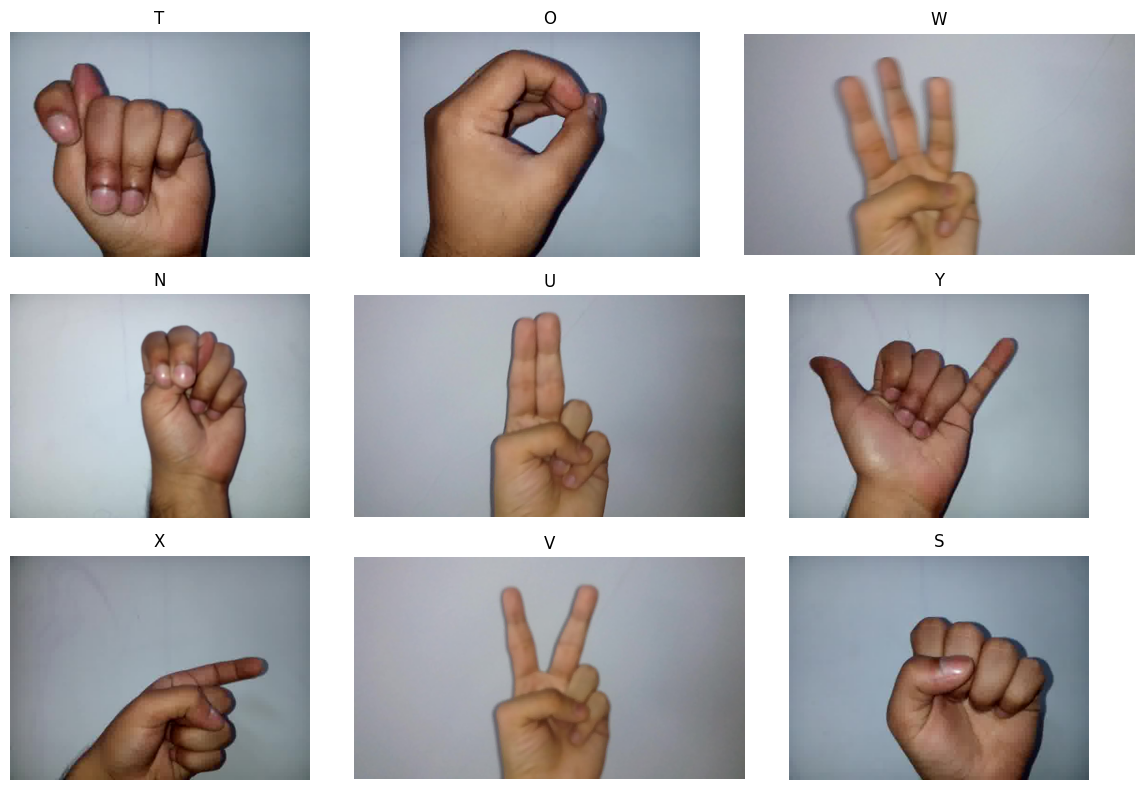

In [7]:
plt.figure(figsize=(12,8))

# Correctly identify the directory containing the actual image categories
# From the previous cell, classes = ['Data'] and data_dir = "/content/drive/MyDrive/PRAICP-1000-IndiSignLang"
# So, the actual categories (A, B, C, etc.) are inside "/content/drive/MyDrive/PRAICP-1000-IndiSignLang/Data"
actual_data_path = os.path.join(data_dir, classes[0]) # This will be "/content/drive/MyDrive/PRAICP-1000-IndiSignLang/Data"

# Now, list the actual sign categories
sign_categories = os.listdir(actual_data_path)

# Iterate through the first 9 actual sign categories
for i, category_name in enumerate(sign_categories[:9]):
  category_dir_path = os.path.join(actual_data_path, category_name)

  # Ensure it's a directory and not empty
  if os.path.isdir(category_dir_path) and len(os.listdir(category_dir_path)) > 0:
    # Get the first image file from the category directory
    img_files = [f for f in os.listdir(category_dir_path) if os.path.isfile(os.path.join(category_dir_path, f))]

    if len(img_files) > 0:
      img_file_name = img_files[0]
      img_path = os.path.join(category_dir_path, img_file_name)
      img = cv2.imread(img_path)

      if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(category_name)
        plt.axis("off")
      else:
        print(f"Warning: Could not load image from {img_path}")
    else:
      print(f"Warning: No image files found in directory {category_dir_path}")
  else:
    print(f"Warning: Directory {category_dir_path} is empty or not a directory.")

plt.tight_layout()
plt.show()

# Step 5: Count Images in Dataset

📖 Explanation

In real projects:

We check dataset balance
Some classes may contain fewer images

Imbalanced datasets reduce accuracy.

In [8]:
for category in classes:
  path = os.path.join(data_dir, category)
  print(category, ":",len(os.listdir(path)), "images")

Data : 24 images


# Step 7: Image Processing

Raw images cannot directly go into CNN.

We preprocess images to:

Reduce noise

Reduce complexity

Standardize dimensions

Improve model learning

In [24]:
img_size = 64

data = []
labels = []

# The 'classes' variable from rj0JHbv_iPzP is ['Data']
# The actual class directories (A, B, C, etc.) are located inside data_dir/classes[0]
actual_data_root = os.path.join(data_dir, classes[0])

# Get the actual list of categories (e.g., ['T', 'O', 'W', ...]) from within 'Data'
real_categories = [d for d in os.listdir(actual_data_root) if os.path.isdir(os.path.join(actual_data_root, d))]
real_categories.sort() # Sort to ensure consistent class_num mapping

for class_idx, category_name in enumerate(real_categories):
    category_path = os.path.join(actual_data_root, category_name)

    for img_file_name in os.listdir(category_path):
        img_path_full = os.path.join(category_path, img_file_name)

        # Filter for actual image files (simple check for common image extensions)
        if not os.path.isfile(img_path_full) or not img_file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
            continue

        try:
            image = cv2.imread(img_path_full)

            if image is None:
                # print(f"Warning: Could not load image from {img_path_full}. Skipping.")
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (img_size, img_size))

            data.append(resized)
            labels.append(class_idx) # Use the enumerated index as the class number

        except Exception as e:
            # print(f"Error processing image {img_path_full}: {e}. Skipping.")
            pass # Silently skip problematic images

data = np.array(data)
labels = np.array(labels)

print("Dataset Shape:", data.shape)
print("Labels Shape:", labels.shape)

Dataset Shape: (4972, 64, 64)
Labels Shape: (4972,)


# Step 8: Visualize Preprocessing Results

This step demonstrates:

Original image
Grayscale image
Resized image

This proves preprocessing was correctly applied.

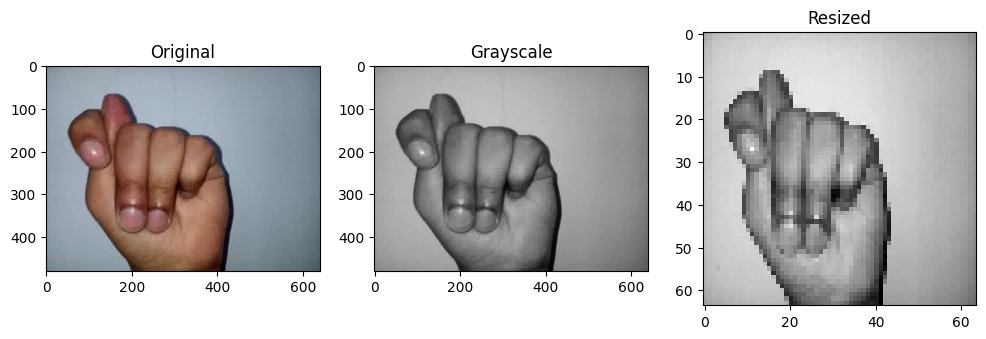

In [21]:
# Determine the path to the directory containing actual sign categories
actual_data_path = os.path.join(data_dir, classes[0]) # e.g., /content/drive/MyDrive/PRAICP-1000-IndiSignLang/Data

# Get the list of actual sign category names (e.g., ['T', 'O', ...])
sign_categories = os.listdir(actual_data_path)

# Ensure there are categories to pick from
if not sign_categories:
    raise ValueError("No sign categories found in the data directory.")

# Select the first category name (e.g., 'T')
first_category_name = sign_categories[0]

# Construct the path to this specific category's directory
first_category_dir = os.path.join(actual_data_path, first_category_name)

# List all files within this category directory
files_in_category = os.listdir(first_category_dir)

# Filter for actual image files (simple check for common image extensions)
image_files = [f for f in files_in_category if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]

# Ensure there's at least one image file
if not image_files:
    raise FileNotFoundError(f"No image files found in the directory: {first_category_dir}")

# Construct the full path to the first image file
sample_path = os.path.join(first_category_dir, image_files[0])


original = cv2.imread(sample_path)

# Add a check in case the image itself is corrupted or unreadable
if original is None:
    raise IOError(f"Failed to load image from {sample_path}. It might be corrupted or not a valid image file.")

original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

gray = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2GRAY
)

resized = cv2.resize(gray, (64,64))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(original_rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(1,3,3)
plt.imshow(resized, cmap='gray')
plt.title("Resized")

plt.show()

# Step 9: Normalize Images

In [22]:
data = data / 255.0
data = data.reshape(-1, 64, 64, 1)

print(data.shape)

(0, 64, 64, 1)


# Step 11: Encode Labels
Machine learning models cannot understand text labels directly.

We convert labels into:

One-Hot Encoding


In [25]:
labels = to_categorical(labels)

# Step 12: Split Dataset
📖 Explanation

Dataset is divided into:

Training set → 80%
Testing set → 20%

Training data teaches model.

Testing data evaluates performance.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (3977, 64, 64)
Testing Shape: (995, 64, 64)


# Step 13: Build CNN Model

Why CNN?

CNN is best for:

Image classification
Pattern recognition
Feature extraction

🔹 Conv2D Layer

Extracts:

Edges
Shapes
Gesture patterns

🔹 MaxPooling Layer

Reduces image size.

Benefits:
Faster processing
Reduces overfitting

🔹 Flatten Layer

Converts features into vector form.

🔹 Dense Layer

Final classification layer.

In [31]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,1)
    )
)

model.add(MaxPooling2D(2,2))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

# Correcting the output units to match the number of actual categories
# `real_categories` contains the 24 actual sign classes
model.add(
    Dense(
        len(real_categories),
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 14: Compile Model
📖 Explanation

Compilation defines:

Optimizer

Loss function

Metrics

In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 15: Train Model
The model learns patterns from training images.

Epochs:

One complete learning cycle

Validation data:

Measures performance during training


In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 196ms/step - accuracy: 0.5233 - loss: 10.9206 - val_accuracy: 0.8764 - val_loss: 0.4441
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 169ms/step - accuracy: 0.9389 - loss: 0.2251 - val_accuracy: 0.9528 - val_loss: 0.1395
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 197ms/step - accuracy: 0.9663 - loss: 0.1138 - val_accuracy: 0.9437 - val_loss: 0.1718
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 214ms/step - accuracy: 0.9829 - loss: 0.0655 - val_accuracy: 0.9849 - val_loss: 0.0654
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 266ms/step - accuracy: 0.9932 - loss: 0.0248 - val_accuracy: 0.9809 - val_loss: 0.0817
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.9982 - loss: 0.0083 - val_accuracy: 0.9839 - val_loss: 0.0627
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 231ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.9839 - val_loss: 0.0667
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 1.0000 - loss: 

# Step 16: Accuracy Visualization

Explanation

This graph compares:

Training accuracy
Validation accuracy

Used to analyze learning performance.


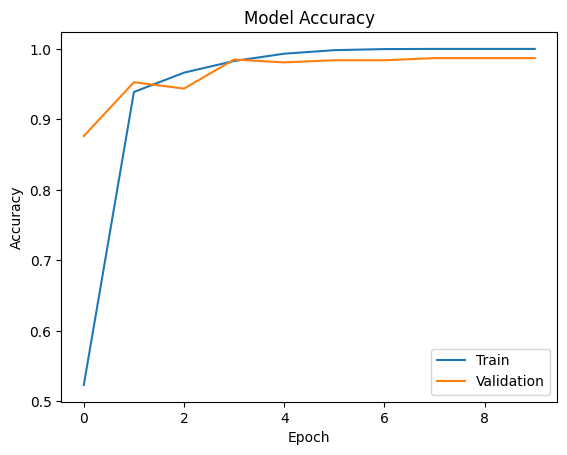

In [34]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

# Step 17: Loss Visualization
📖 Explanation

Loss measures prediction error.

Lower loss indicates:

Better learning
Better predictions

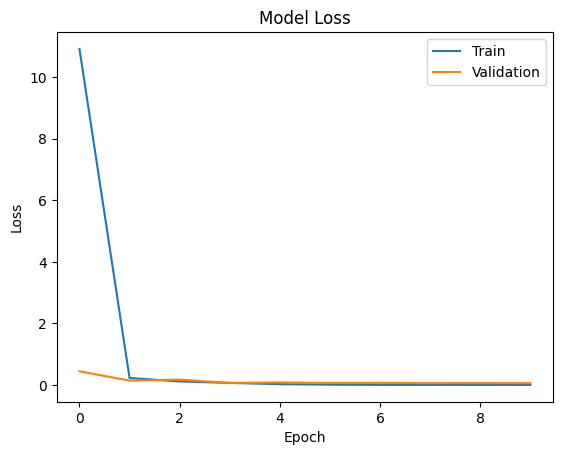

In [35]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

# Step 18: Evaluate Model
📖 Explanation

Model performance is tested on unseen data.

In [36]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.9869 - loss: 0.0571
Accuracy: 0.9869346618652344


# Step 19: Confusion Matrix

Explanation

Confusion matrix shows:

Correct predictions
Wrong predictions

Useful for model analysis.

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step


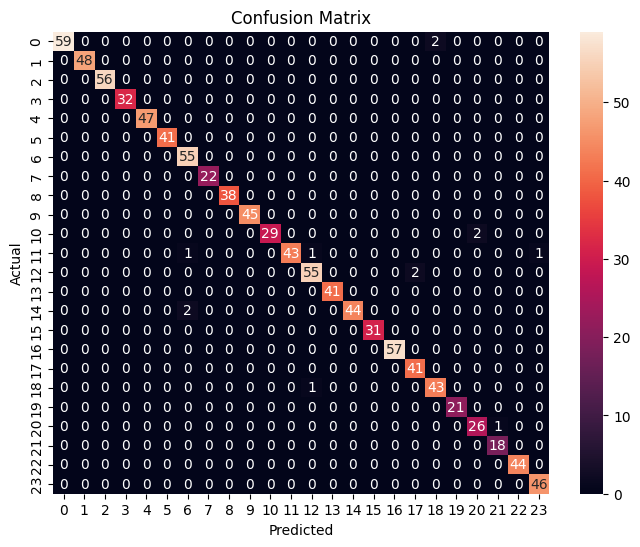

In [37]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Step 20: Classification Report
📖 Explanation

Displays:

Precision

Recall

F1-score

These are standard evaluation metrics.

In [38]:
print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        61
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        32
           4       1.00      1.00      1.00        47
           5       1.00      1.00      1.00        41
           6       0.95      1.00      0.97        55
           7       1.00      1.00      1.00        22
           8       1.00      1.00      1.00        38
           9       1.00      1.00      1.00        45
          10       1.00      0.94      0.97        31
          11       1.00      0.93      0.97        46
          12       0.96      0.96      0.96        57
          13       1.00      1.00      1.00        41
          14       1.00      0.96      0.98        46
          15       1.00      1.00      1.00        31
          16       1.00      1.00      1.00        57
          17       0.95    

# Step 21: Create Prediction System

Explanation

This function predicts ISL sign from new image.

Steps:

Read image

Preprocess image

Predict class

In [39]:
def predict_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    img = cv2.resize(img, (64,64))

    img = img / 255.0

    img = img.reshape(1,64,64,1)

    prediction = model.predict(img)

    return classes[np.argmax(prediction)]

# Step 22: Test Prediction
📖 Explanation

Testing the final system using unseen image.

In [40]:
result = predict_image("/content/drive/MyDrive/PRAICP-1000-IndiSignLang/Data/A/002.jpg")

print("Predicted Sign:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Sign: Data


# tep 23: Final Conclusion
📖 Explanation

An end-to-end ISL Recognition system was successfully built using Deep Learning.

# Technologies Used
- Python
- OpenCV
- TensorFlow/Keras
- CNN
- NumPy
- Matplotlib

# Project Features
- Image preprocessing
- CNN-based classification
- Visualization
- Prediction system
- Evaluation metrics
# Future Improvements
- Real-time webcam recognition
- Mobile app deployment
- More gesture classes
- Higher accuracy using transfer learning